<a href="https://colab.research.google.com/github/Janpu-Hou/IoT_Cybersecurity/blob/main/IoT23_Good_SLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Download the dataset
!wget https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz

# Extract the dataset
!tar -xzvf iot_23_datasets_small.tar.gz

print("Download and extraction complete.")
import pandas as pd
import numpy as np
from collections import Counter

# Assuming 'files' variable is available from previous !find command
# If not, uncomment and run: files = !find opt/Malware-Project -name "*.labeled"

def map_to_detailed_label(label):
    label = str(label)
    if 'Benign' in label: return 'Benign'
    elif 'DDoS' in label: return 'DDoS'
    elif 'PartOfAHorizontalPortScan' in label: return 'PortScan'
    elif 'C&C' in label: return 'C&C'
    elif 'Attack' in label: return 'Attack'
    elif 'FileDownload' in label: return 'FileDownload'
    elif 'Malicious' in label:
        parts = label.split('   ')
        for part in parts:
            if part not in ['(empty)', 'Malicious', '-'] and part.strip() != '':
                return part.strip()
        return 'Other Malicious'
    else: return 'Other'

def get_all_detailed_labels(file_paths, chunksize=100000):
    all_labels = []
    for file_path in file_paths:
        print(f"Processing {file_path}...")
        try:
            for chunk in pd.read_table(file_path, sep='\t', comment='#', header=None, low_memory=False, chunksize=chunksize):
                chunk.columns = [
                    'ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
                    'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes',
                    'conn_state', 'local_orig', 'local_resp', 'missed_bytes',
                    'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label'
                ]
                all_labels.extend(chunk['label'].apply(map_to_detailed_label).tolist())
        except Exception as e:
            print(f"Error reading {file_path}: {e}. Skipping.")
    return all_labels

# Make sure the 'files' variable is correctly defined, if not, define it.
if 'files' not in locals():
    files = !find opt/Malware-Project -name "*.labeled"

# Get all detailed labels from the entire dataset
full_dataset_detailed_labels = get_all_detailed_labels(files)

# Display the distribution of detailed labels for the entire dataset
label_counts = pd.Series(full_dataset_detailed_labels).value_counts()
print("\nFull Dataset Detailed Label Distribution:")
display(label_counts)

--2026-08-01 02:39:30--  https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz
Resolving mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)... 147.32.82.194
Connecting to mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)|147.32.82.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9373916249 (8.7G) [application/x-gzip]
Saving to: ‘iot_23_datasets_small.tar.gz’

iot_23_datasets_sma 100%[===================>]   8.73G  15.3MB/s    in 9m 15s  

2026-08-01 02:48:47 (16.1 MB/s) - ‘iot_23_datasets_small.tar.gz’ saved [9373916249/9373916249]

opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-17-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-20-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-21-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT

,count
PortScan,213853817
Okiru,60990708
Benign,30858735
DDoS,19538713
C&C,56598
Attack,9401
Other,1956
FileDownload,18


In [3]:
import pandas as pd
import numpy as np
import warnings # Import warnings to manage FutureWarnings

def get_balanced_samples(file_paths, max_available_counts, samples_per_class=5000, chunksize=100000):
    """Loads a balanced sample of IoT-23 conn.log.labeled data into a pandas DataFrame.

    Args:
        file_paths (list): List of paths to the .labeled files.
        max_available_counts (dict): A dictionary with each detailed label as key and its total count in the dataset as value.
        samples_per_class (int): The target number of samples for each detailed label.
        chunksize (int): The number of rows to read at a time.

    Returns:
        pd.DataFrame: A balanced DataFrame containing sampled data.
    """
    # Use keys from max_available_counts to ensure all identified labels are targeted
    target_labels = list(max_available_counts.keys())
    sampled_data = {label: [] for label in target_labels}
    current_counts = {label: 0 for label in target_labels}
    total_collected_rows = 0

    # Column names for the dataset
    column_names = [
        'ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
        'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes',
        'conn_state', 'local_orig', 'local_resp', 'missed_bytes',
        'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label'
    ]
    # Numeric columns to handle NaN values
    numeric_cols = ['duration', 'orig_bytes', 'resp_bytes', 'id.orig_p', 'id.resp_p']

    # Suppress the specific FutureWarning related to replace downcasting
    with warnings.catch_warnings():
        warnings.simplefilter(action='ignore', category=FutureWarning)

        for file_path in file_paths:
            print(f"Processing {file_path} for balanced sampling...")
            try:
                # Read in chunks to manage memory
                for chunk in pd.read_table(file_path, sep='\t', comment='#', header=None, low_memory=False, chunksize=chunksize):
                    chunk.columns = column_names

                    # Apply numeric conversion and NaN filling as done in load_iot_data
                    for col in numeric_cols:
                        chunk[col] = pd.to_numeric(chunk[col].replace('-', np.nan), errors='coerce')
                    chunk = chunk.fillna(0)

                    # Map to detailed labels
                    chunk['detailed_label'] = chunk['label'].apply(map_to_detailed_label)

                    # Sample rows for each detailed label
                    for label_val, group in chunk.groupby('detailed_label'):
                        if label_val in sampled_data: # Only process labels we are targeting
                            # Determine the actual target count for this label (min of samples_per_class or max available)
                            target_count_for_label = min(samples_per_class, max_available_counts.get(label_val, 0))

                            if current_counts[label_val] < target_count_for_label:
                                remaining_slots = target_count_for_label - current_counts[label_val]
                                rows_to_add = min(len(group), remaining_slots)

                                # Use .sample to avoid bias and extend with dictionaries
                                if rows_to_add > 0:
                                    sampled_data[label_val].extend(group.sample(n=rows_to_add, random_state=42).to_dict('records'))
                                    current_counts[label_val] += rows_to_add
                                    total_collected_rows += rows_to_add

                    # Check if we have collected enough samples for all desired classes based on their actual limits
                    all_targets_met = all(
                        current_counts[label_key] >= min(samples_per_class, max_available_counts.get(label_key, 0))
                        for label_key in target_labels
                    )

                    if all_targets_met:
                        print(f"Reached target samples for all classes. Collected {total_collected_rows} rows.")
                        final_df = pd.DataFrame([row for sublist in sampled_data.values() for row in sublist])
                        return final_df

            except Exception as e:
                print(f"Error reading {file_path}: {e}. Skipping.")

    # Concatenate all collected samples into a single DataFrame if loop finishes without early exit
    final_df = pd.DataFrame([row for sublist in sampled_data.values() for row in sublist])
    print(f"Finished sampling. Total collected rows: {len(final_df)}.")
    return final_df
 # Ensure 'files' is defined, if not, re-run the !find command
if 'files' not in locals():
    files = !find opt/Malware-Project -name "*.labeled"

# Ensure full_dataset_detailed_labels and label_counts are available from previous steps.
# If not, regenerate them.
if 'full_dataset_detailed_labels' not in locals() or 'label_counts' not in locals():
    print("Recalculating full_dataset_detailed_labels...")
    full_dataset_detailed_labels = get_all_detailed_labels(files)
    label_counts = pd.Series(full_dataset_detailed_labels).value_counts()
    print("Full Dataset Detailed Label Distribution (Recalculated):")
    display(label_counts)

# Convert label_counts Series to a dictionary for max_available_counts
max_available_counts = label_counts.to_dict()

# Create the balanced dataset
balanced_df = get_balanced_samples(files, max_available_counts, samples_per_class=5000)
iot_data = balanced_df.copy()
iot_data.to_csv('iot_data.csv', index=False)
print("\nBalanced Dataset Head:")
display(balanced_df.head())

print("\nBalanced Dataset Detailed Label Distribution:")
display(balanced_df['detailed_label'].value_counts())

Processing opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-35-1/bro/conn.log.labeled for balanced sampling...
Processing opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-9-1/bro/conn.log.labeled for balanced sampling...
Processing opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-4-1/bro/conn.log.labeled for balanced sampling...
Processing opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-7-1/Somfy-01/bro/conn.log.labeled for balanced sampling...
Processing opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-44-1/bro/conn.log.labeled for balanced sampling...
Processing opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-52-1/bro/conn.log.labeled for balanced sampling...
Processing opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-8-1/bro/conn.log.labeled for balanced sampling...
Processing opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-60-1/bro/con

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,detailed_label
0,1.532526e+09,CApdsj281GdHQus995,192.168.100.111,59185,46.130.220.209,23,tcp,-,0.0,0.0,...,-,-,0,S,1,40,0,0,(empty) Malicious PartOfAHorizontalPortScan,PortScan
1,1.532526e+09,CFzmlhPl6hjf78SN5,192.168.100.111,24299,195.247.12.23,81,tcp,-,0.0,0.0,...,-,-,0,S,1,40,0,0,(empty) Malicious PartOfAHorizontalPortScan,PortScan
2,1.532526e+09,Cw8JynZ6zXL9400Qk,192.168.100.111,63883,43.10.26.67,23,tcp,-,0.0,0.0,...,-,-,0,S,1,40,0,0,(empty) Malicious PartOfAHorizontalPortScan,PortScan
3,1.532526e+09,CP1Vsu27A5wBycPsQ,192.168.100.111,8155,205.21.33.94,81,tcp,-,0.0,0.0,...,-,-,0,S,1,40,0,0,(empty) Malicious PartOfAHorizontalPortScan,PortScan
4,1.532526e+09,CyUYdi3iSNZaic3rm9,192.168.100.111,56596,1.209.174.94,23,tcp,-,0.0,0.0,...,-,-,0,S,1,40,0,0,(empty) Malicious PartOfAHorizontalPortScan,PortScan



Balanced Dataset Detailed Label Distribution:


,count
detailed_label,
PortScan,5000
Okiru,5000
Benign,5000
DDoS,5000
C&C,5000
Attack,5000
Other,1956
FileDownload,18


In [5]:
from sklearn.model_selection import train_test_split

# Assuming balanced_df is already loaded in the environment.
# If not, you would load it first:
balanced_df = pd.read_csv('iot_data.csv')

# Split the DataFrame into training and testing sets
# Using stratify on 'detailed_label' to maintain class distribution in both sets
# Using random_state for reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    balanced_df.drop('detailed_label', axis=1),
    balanced_df['detailed_label'],
    test_size=0.2, # 20% for testing, 80% for training
    random_state=42,
    stratify=balanced_df['detailed_label'] # Ensure class distribution is preserved
)

# Recombine features and labels for train and test sets
balanced_train_df = pd.concat([X_train, y_train], axis=1)
balanced_test_df = pd.concat([X_test, y_test], axis=1)

# Save the training and testing sets to CSV files
balanced_train_df.to_csv('balanced_train.csv', index=False)
balanced_test_df.to_csv('balanced_test.csv', index=False)

print(f"Training data saved to 'balanced_train.csv' with shape: {balanced_train_df.shape}")
print(f"Testing data saved to 'balanced_test.csv' with shape: {balanced_test_df.shape}")

Training data saved to 'balanced_train.csv' with shape: (25579, 22)
Testing data saved to 'balanced_test.csv' with shape: (6395, 22)


Original numerical dimension: 11
Reduced Saab dimension (95% energy): 8
Sample transformed min values: [1.00000000e-06 1.00000000e-06 1.00000000e-06 9.99999997e-07
 9.99999997e-07 9.99999997e-07 1.00000000e-06 9.99999997e-07]
Saved feature_matrix.csv successfully! Shape: (25579, 9)


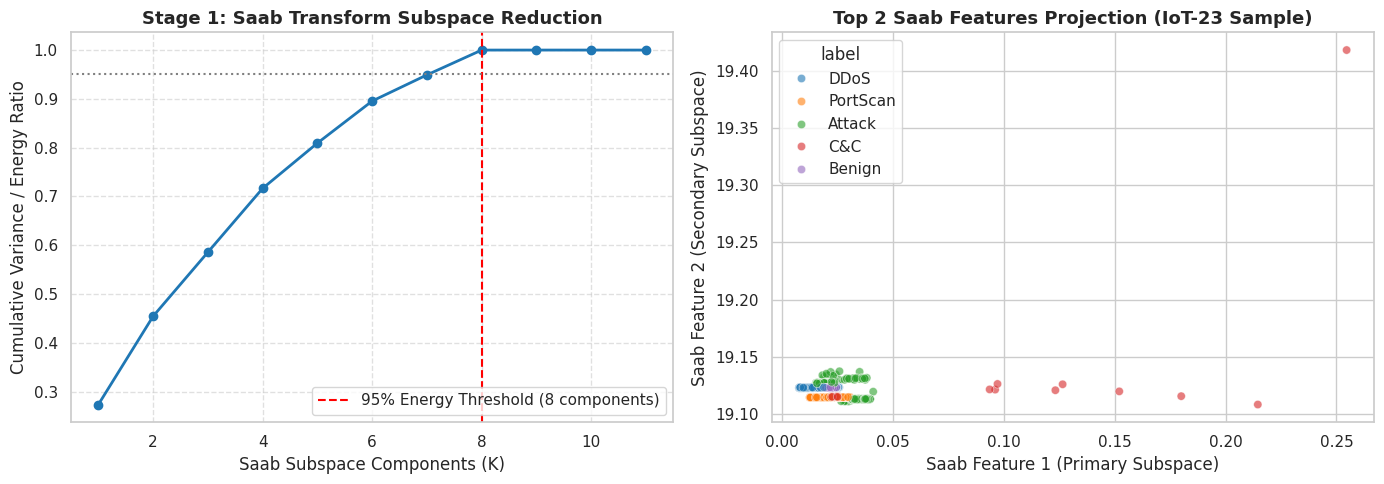

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

class SaabTransform:
    def __init__(self, energy_threshold=0.95, n_components=None):
        self.energy_threshold = energy_threshold
        self.n_components = n_components
        self.mean = None
        self.scaler = None
        self.components_ = None
        self.bias_ = None
        self.explained_variance_ratio_ = None

    def fit_transform(self, X):
        # 1. Standardize features to zero mean, unit variance
        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)
        self.mean = self.scaler.mean_

        # 2. Compute Covariance and Eigendecomposition
        cov = np.cov(X_scaled, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # Sort descending order
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Calculate explained variance ratio
        total_var = np.sum(eigenvalues)
        self.explained_variance_ratio_ = eigenvalues / total_var
        cum_var = np.cumsum(self.explained_variance_ratio_)

        # Determine number of components
        if self.n_components is None:
            self.n_components = np.argmax(cum_var >= self.energy_threshold) + 1

        self.components_ = eigenvectors[:, :self.n_components]

        # 3. Project centered data onto selected principal components
        Y = np.dot(X_scaled, self.components_)

        # 4. Compute Adjusted Bias so all features are non-negative
        # b_k = max(-Y_k) + epsilon (or exact offset)
        self.bias_ = np.abs(np.min(Y, axis=0)) + 1e-6
        Z = Y + self.bias_

        return Z

# Load dataset
df = pd.read_csv('./balanced_train.csv')

# Identify numerical columns for feature extraction
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'ts' if it's treated as a timestamp and not a feature to be scaled
# For now, let's assume 'ts' is a numerical feature for scaling.

# Ensure 'label' and 'detailed_label' are not included in features,
# even if they might appear numerical (e.g., if one-hot encoded later)
# They are already removed from `df` but this is an extra check.
feature_cols = [col for col in numeric_cols if col not in ['label', 'detailed_label']]

X = df[feature_cols].values
y = df['label'].values # Keep original 'label' for mapping purposes if needed later or use 'detailed_label'

# Fit and transform via Saab
saab = SaabTransform(energy_threshold=0.95)
X_saab = saab.fit_transform(X)

print(f"Original numerical dimension: {X.shape[1]}")
print(f"Reduced Saab dimension (95% energy): {X_saab.shape[1]}")
print(f"Sample transformed min values: {X_saab.min(axis=0)}")

# Construct feature matrix dataframe
saab_cols = [f'saab_feat_{i+1}' for i in range(X_saab.shape[1])]
df_feature_matrix = pd.DataFrame(X_saab, columns=saab_cols)
# Use 'detailed_label' for plotting and saving, as it's the more processed label
df_feature_matrix['label'] = df['detailed_label']

# Save to feature_matrix.csv
df_feature_matrix.to_csv('feature_matrix.csv', index=False)
print("Saved feature_matrix.csv successfully! Shape:", df_feature_matrix.shape)

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative Variance / Energy Ratio
cum_var = np.cumsum(saab.explained_variance_ratio_)
axes[0].plot(range(1, len(cum_var) + 1), cum_var, 'o-', color='#1f77b4', linewidth=2)
axes[0].axvline(x=saab.n_components, color='red', linestyle='--', label=f'95% Energy Threshold ({saab.n_components} components)')
axes[0].axhline(y=0.95, color='gray', linestyle=':')
axes[0].set_xlabel('Saab Subspace Components (K)', fontsize=12)
axes[0].set_ylabel('Cumulative Variance / Energy Ratio', fontsize=12)
axes[0].set_title('Stage 1: Saab Transform Subspace Reduction', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Scatter / Box plot of top 2 Saab features across top classes
top_classes = df['detailed_label'].value_counts().head(5).index # Use detailed_label
df_top = df_feature_matrix[df_feature_matrix['label'].isin(top_classes)]

sns.scatterplot(
    data=df_top.sample(5000, random_state=42),
    x='saab_feat_1', y='saab_feat_2', hue='label',
    alpha=0.6, palette='tab10', ax=axes[1]
)
axes[1].set_title('Top 2 Saab Features Projection (IoT-23 Sample)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Saab Feature 1 (Primary Subspace)', fontsize=12)
axes[1].set_ylabel('Saab Feature 2 (Secondary Subspace)', fontsize=12)

plt.tight_layout()
plt.savefig('saab_reduction_summary.png', dpi=300)
plt.show()


--- DFT Feature Loss Ranking (Lower Loss = Stronger Discriminant Power) ---
saab_feat_7    : DFT Loss = 2.15135  [SELECTED]
saab_feat_3    : DFT Loss = 2.50349  [SELECTED]
saab_feat_6    : DFT Loss = 2.60159  [SELECTED]
saab_feat_5    : DFT Loss = 2.76182  [SELECTED]
saab_feat_4    : DFT Loss = 2.76330  [SELECTED]
saab_feat_8    : DFT Loss = 2.76355  [SELECTED]
saab_feat_1    : DFT Loss = 2.76400  [SELECTED]
saab_feat_2    : DFT Loss = 2.76403  [SELECTED]

Saved Stage 2 pruned matrix to 'pruned_feature_matrix.csv'!


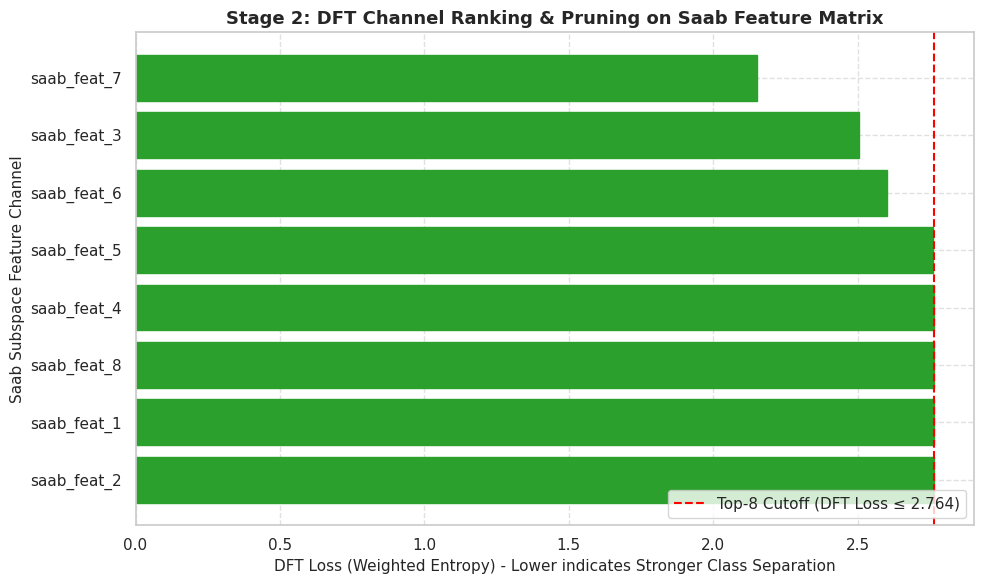

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class DiscriminantFeatureTest:
    """
    Stage 2 Green Learning DFT (Discriminant Feature Test) Evaluator & Pruner[cite: 1, 2].
    Computes minimum weighted Shannon entropy (DFT Loss) across 1D feature bins[cite: 1, 2].
    """
    def __init__(self, n_bins=16, top_k=10):
        self.n_bins = n_bins
        self.top_k = top_k
        self.dft_scores_ = {}
        self.selected_features_ = []

    def _compute_single_dft_loss(self, x, y):
        """Computes DFT loss (min weighted entropy) for a single feature vector."""
        if np.min(x) == np.max(x):
            return 1.0 # Max entropy / no separation

        # 1. Discretize continuous feature into bins[cite: 2]
        bins = np.linspace(np.min(x), np.max(x), self.n_bins + 1)
        bin_idx = np.digitize(x, bins[:-1])

        unique_labels, y_encoded = np.unique(y, return_inverse=True)
        N = len(x)
        min_entropy = float('inf')

        # 2. Iterate through candidate split thresholds across bins[cite: 2]
        for b in range(1, self.n_bins):
            left_mask = bin_idx <= b
            right_mask = ~left_mask

            N_L = np.sum(left_mask)
            N_R = np.sum(right_mask)

            if N_L == 0 or N_R == 0:
                continue

            # Entropy of left partition[cite: 2]
            _, counts_L = np.unique(y_encoded[left_mask], return_counts=True)
            probs_L = counts_L / N_L
            H_L = -np.sum(probs_L * np.log2(probs_L + 1e-12))

            # Entropy of right partition[cite: 2]
            _, counts_R = np.unique(y_encoded[right_mask], return_counts=True)
            probs_R = counts_R / N_R
            H_R = -np.sum(probs_R * np.log2(probs_R + 1e-12))

            # Weighted Shannon entropy[cite: 2]
            weighted_H = (N_L / N) * H_L + (N_R / N) * H_R

            if weighted_H < min_entropy:
                min_entropy = weighted_H

        return min_entropy

    def fit(self, X_df, y):
        """Ranks features in X_df by DFT Loss[cite: 2]."""
        self.dft_scores_ = {}
        feature_cols = [c for c in X_df.columns if c != 'label']

        for col in feature_cols:
            loss = self._compute_single_dft_loss(X_df[col].values, y)
            self.dft_scores_[col] = loss

        # Sort features ascending by DFT Loss (lower = more discriminant)[cite: 2]
        sorted_feats = sorted(self.dft_scores_.items(), key=lambda x: x[1])
        self.selected_features_ = [f[0] for f in sorted_feats[:self.top_k]]
        return self

    def transform(self, X_df):
        """Prunes feature space to keep only top-K DFT channels[cite: 2]."""
        # ✅ FIX 1: Add .copy() to ensure df_pruned is an independent DataFrame, not a view
        return X_df[self.selected_features_].copy()

    def fit_transform(self, X_df, y):
        self.fit(X_df, y)
        return self.transform(X_df)


# ==========================================
# Execution on feature_matrix.csv
# ==========================================
if __name__ == '__main__':
    # 1. Load Stage 1 Feature Matrix[cite: 2]
    df_feat = pd.read_csv('feature_matrix.csv')
    y = df_feat['label'].values

    # 2. Run Stage 2 DFT Pruning (e.g., select top 10 channels)[cite: 2]
    dft = DiscriminantFeatureTest(n_bins=16, top_k=10)
    df_pruned = dft.fit_transform(df_feat, y)

    print("\n--- DFT Feature Loss Ranking (Lower Loss = Stronger Discriminant Power) ---")
    sorted_dft = sorted(dft.dft_scores_.items(), key=lambda x: x[1])
    for feat, loss in sorted_dft:
        status = "[SELECTED]" if feat in dft.selected_features_ else "[PRUNED]"
        print(f"{feat:15s}: DFT Loss = {loss:.5f}  {status}")

    # ✅ FIX 2: Use .loc to set new column safely
    df_pruned.loc[:, 'label'] = y

    # Save pruned matrix ready for Stage 3 (SLM Classifier)[cite: 1, 2]
    df_pruned.to_csv('pruned_feature_matrix.csv', index=False)
    print("\nSaved Stage 2 pruned matrix to 'pruned_feature_matrix.csv'!")

    # Plotting[cite: 2]
    df_dft = pd.DataFrame(sorted_dft, columns=['Saab_Feature', 'DFT_Loss'])

    plt.figure(figsize=(10, 6))
    bars = plt.barh(df_dft['Saab_Feature'][::-1], df_dft['DFT_Loss'][::-1], color='#2b5c8f', edgecolor='black')

    num_features_available = len(sorted_dft)
    num_features_to_color = min(dft.top_k, num_features_available)

    # Color the selected features (those with lowest DFT loss)
    # The bars are plotted in reverse order, so the 'best' features (lowest DFT_Loss) are at higher indices in the `bars` list.
    for i in range(num_features_available):
        if i >= (num_features_available - num_features_to_color):
            bars[i].set_color('#2ca02c')

    # Adjusting the axvline logic to use the actual number of selected features
    if num_features_to_color > 0:
        # The cutoff should be at the DFT loss of the 'last' selected feature in terms of rank
        # (i.e., the one with the highest DFT loss among the selected ones).
        cutoff_dft_loss = sorted_dft[num_features_to_color - 1][1]
        plt.axvline(x=cutoff_dft_loss, color='red', linestyle='--', label=f'Top-{num_features_to_color} Cutoff (DFT Loss \u2264 {cutoff_dft_loss:.3f})')

    plt.xlabel('DFT Loss (Weighted Entropy) - Lower indicates Stronger Class Separation', fontsize=11)
    plt.ylabel('Saab Subspace Feature Channel', fontsize=11)
    plt.title('Stage 2: DFT Channel Ranking & Pruning on Saab Feature Matrix', fontsize=13, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('dft_channel_ranking.png', dpi=300)
    plt.show()

Computing Stage 2 DFT losses...
Training Stage 3 SLM Classifier...

--- Stage 3 SLM Evaluation ---
Accuracy: 96.23%

              precision    recall  f1-score   support

      Attack     1.0000    1.0000    1.0000       800
      Benign     0.8081    1.0000    0.8939       800
         C&C     0.9987    0.9875    0.9931       800
        DDoS     0.9968    0.7725    0.8704       800
FileDownload     1.0000    0.6667    0.8000         3
       Okiru     1.0000    1.0000    1.0000       800
       Other     1.0000    1.0000    1.0000       313
    PortScan     1.0000    1.0000    1.0000       800

    accuracy                         0.9623      5116
   macro avg     0.9754    0.9283    0.9447      5116
weighted avg     0.9693    0.9623    0.9619      5116

Saved confusion matrix plot to 'slm_confusion_matrix.png'!


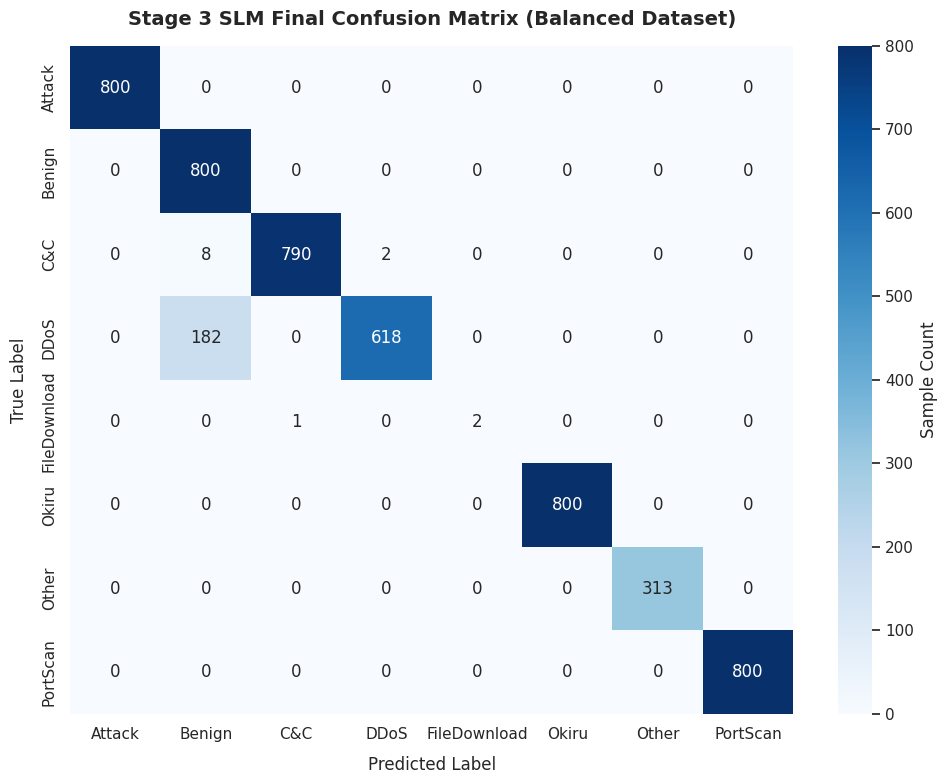

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


class SLMNode:
    """
    A single node in the Subspace Learning Machine Tree (Stage 3).
    Implements Local Oblique Projection Weighting via inverse DFT-loss biasing.
    """
    def __init__(self, depth=0, max_depth=6, min_samples_split=10,
                 n_projections=30, active_features_range=(2, 5), n_bins=16):
        self.depth = depth
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_projections = n_projections
        self.active_features_range = active_features_range
        self.n_bins = n_bins

        self.is_leaf = False
        self.prediction = None
        self.left = None
        self.right = None

        self.projection_vector = None   # Vector 'a'
        self.selected_indices = None   # Active feature indices
        self.threshold = None          # Scalar threshold 't'

    def _compute_entropy(self, y):
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-12))

    def _generate_dft_weighted_projection(self, num_features, dft_losses):
        k = np.random.randint(self.active_features_range[0],
                              min(self.active_features_range[1] + 1, num_features + 1))
        active_indices = np.random.choice(num_features, size=k, replace=False)

        raw_coefficients = np.random.uniform(-1.0, 1.0, size=k)
        selected_dft_losses = dft_losses[active_indices]
        inv_dft_weights = 1.0 / (selected_dft_losses + 1e-8)

        a_k = raw_coefficients * inv_dft_weights

        norm = np.linalg.norm(a_k)
        if norm > 0:
            a_k = a_k / norm

        return active_indices, a_k

    def fit(self, X, y, dft_losses):
        unique_classes, counts = np.unique(y, return_counts=True)
        self.prediction = unique_classes[np.argmax(counts)]

        if (self.depth >= self.max_depth or
            len(y) < self.min_samples_split or
            len(unique_classes) == 1):
            self.is_leaf = True
            return

        best_gain = -1.0
        best_indices = None
        best_a_k = None
        best_threshold = None

        current_entropy = self._compute_entropy(y)
        N = len(y)

        for _ in range(self.n_projections):
            indices, a_k = self._generate_dft_weighted_projection(X.shape[1], dft_losses)
            X_projected = np.dot(X[:, indices], a_k)

            bins = np.linspace(np.min(X_projected), np.max(X_projected), self.n_bins + 1)
            for t in bins[1:-1]:
                left_mask = X_projected <= t
                right_mask = ~left_mask

                N_L, N_R = np.sum(left_mask), np.sum(right_mask)
                if N_L == 0 or N_R == 0:
                    continue

                H_L = self._compute_entropy(y[left_mask])
                H_R = self._compute_entropy(y[right_mask])
                weighted_H = (N_L / N) * H_L + (N_R / N) * H_R
                info_gain = current_entropy - weighted_H

                if info_gain > best_gain:
                    best_gain = info_gain
                    best_indices = indices
                    best_a_k = a_k
                    best_threshold = t

        if best_gain <= 0 or best_indices is None:
            self.is_leaf = True
            return

        self.selected_indices = best_indices
        self.projection_vector = best_a_k
        self.threshold = best_threshold

        X_projected_best = np.dot(X[:, best_indices], best_a_k)
        left_mask = X_projected_best <= best_threshold
        right_mask = ~left_mask

        self.left = SLMNode(self.depth + 1, self.max_depth, self.min_samples_split,
                            self.n_projections, self.active_features_range, self.n_bins)
        self.right = SLMNode(self.depth + 1, self.max_depth, self.min_samples_split,
                             self.n_projections, self.active_features_range, self.n_bins)

        self.left.fit(X[left_mask], y[left_mask], dft_losses)
        self.right.fit(X[right_mask], y[right_mask], dft_losses)

    def predict_one(self, x):
        if self.is_leaf:
            return self.prediction

        val = np.dot(x[self.selected_indices], self.projection_vector)
        if val <= self.threshold:
            return self.left.predict_one(x)
        else:
            return self.right.predict_one(x)

# Best Parameters: max_depth=8, n_projections=40, n_bins=32, active_features_range=(3, 6)
class SubspaceLearningMachine:
    def __init__(self, max_depth=8, min_samples_split=10, n_projections=30, n_bins=32, random_state=42):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_projections = n_projections
        self.n_bins = n_bins
        self.random_state = random_state
        self.root = None

    def fit(self, X, y, dft_losses):
        np.random.seed(self.random_state)
        self.root = SLMNode(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            n_projections=self.n_projections,
            n_bins=self.n_bins
        )
        self.root.fit(X, y, dft_losses)

    def predict(self, X):
        return np.array([self.root.predict_one(x) for x in X])


def compute_dft_losses(X, y, n_bins=16):
    dft_losses = []
    unique_labels, y_encoded = np.unique(y, return_inverse=True)
    N = len(y)

    for col_idx in range(X.shape[1]):
        x = X[:, col_idx]
        if np.min(x) == np.max(x):
            dft_losses.append(1.0)
            continue

        bins = np.linspace(np.min(x), np.max(x), n_bins + 1)
        bin_idx = np.digitize(x, bins[:-1])
        min_entropy = float('inf')

        for b in range(1, n_bins):
            left_mask = bin_idx <= b
            right_mask = ~left_mask
            N_L, N_R = np.sum(left_mask), np.sum(right_mask)
            if N_L == 0 or N_R == 0:
                continue
            _, counts_L = np.unique(y_encoded[left_mask], return_counts=True)
            H_L = -np.sum((counts_L / N_L) * np.log2((counts_L / N_L) + 1e-12))
            _, counts_R = np.unique(y_encoded[right_mask], return_counts=True)
            H_R = -np.sum((counts_R / N_R) * np.log2((counts_R / N_R) + 1e-12))

            weighted_H = (N_L / N) * H_L + (N_R / N) * H_R
            if weighted_H < min_entropy:
                min_entropy = weighted_H

        dft_losses.append(min_entropy)

    return np.array(dft_losses)


# ==========================================
# Execution & Plot Generation
# ==========================================
if __name__ == '__main__':
    # 1. Load dataset
    df_bal = pd.read_csv('pruned_feature_matrix.csv') # Changed filename
    X_cols = [c for c in df_bal.columns if c != 'label']
    X = df_bal[X_cols].values
    y = df_bal['label'].values

    # 2. Compute DFT losses
    print("Computing Stage 2 DFT losses...")
    dft_losses = compute_dft_losses(X, y)

    # 3. Stratified Train-Test Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 4. Fit SLM
    print("Training Stage 3 SLM Classifier...")
    slm = SubspaceLearningMachine(max_depth=6, n_projections=30, random_state=42)
    slm.fit(X_train, y_train, dft_losses)

    # 5. Evaluate
    y_pred = slm.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n--- Stage 3 SLM Evaluation ---")
    print(f"Accuracy: {acc * 100:.2f}%\n")
    print(classification_report(y_test, y_pred, digits=4))

    # 6. Plot & Save Confusion Matrix
    class_names = sorted(np.unique(y_test))
    cm = confusion_matrix(y_test, y_pred, labels=class_names)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Sample Count'}
    )

    plt.title('Stage 3 SLM Final Confusion Matrix (Balanced Dataset)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
    plt.ylabel('True Label', fontsize=12, labelpad=10)
    plt.tight_layout()

    # Save high-resolution plot
    plt.savefig('slm_confusion_matrix.png', dpi=300)
    print("Saved confusion matrix plot to 'slm_confusion_matrix.png'!")
    plt.show()

In [11]:
import pandas as pd
import numpy as np

# Load the full dataset (pruned_feature_matrix.csv) and the original balanced_train.csv
# We need the original features from balanced_train.csv to engineer new ones.
# df_full contains the Saab transformed features and labels.
# We will add new engineered features to df_full.

df_original_full = pd.read_csv('./balanced_train.csv')
df_pruned = pd.read_csv('pruned_feature_matrix.csv') # This contains the Saab features and labels

# Ensure both dataframes align on index or a common identifier if operations are row-wise.
# For simplicity, assuming they correspond row-wise after previous processing.
# If `df_original_full` was the base for `df_pruned`, then their indices should match.
# Let's verify and then merge/concat if needed, or extract original features directly.

# For feature engineering, we need the original numeric features. Let's get them from df_original_full.
# And the detailed labels from df_pruned for 'Benign' vs 'DDoS' filtering.

# Select the original features identified as highly influential, plus other relevant numeric ones
selected_original_features = [
    'ts', 'id.orig_p', 'id.resp_p', 'duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts'
]

# Create a temporary DataFrame with original features and detailed labels
df_temp = df_original_full[selected_original_features].copy()
df_temp['detailed_label'] = df_original_full['detailed_label'] # Add detailed label for filtering

# --- Feature Engineering ---

# 1. Port Difference and Ratio
df_temp['port_diff'] = np.abs(df_temp['id.orig_p'] - df_temp['id.resp_p'])
df_temp['port_ratio'] = df_temp['id.orig_p'] / (df_temp['id.resp_p'] + 1e-6) # Add epsilon to avoid division by zero

# 2. Bytes per Packet (Original and Response)
df_temp['orig_bytes_per_pkt'] = df_temp['orig_bytes'] / (df_temp['orig_pkts'] + 1e-6)
df_temp['resp_bytes_per_pkt'] = df_temp['resp_bytes'] / (df_temp['resp_pkts'] + 1e-6)

# 3. Log Transforms for highly skewed features
# Use log1p to handle zero values gracefully (log(1+x))
df_temp['log_duration'] = np.log1p(df_temp['duration'])
df_temp['log_orig_bytes'] = np.log1p(df_temp['orig_bytes'])
df_temp['log_resp_bytes'] = np.log1p(df_temp['resp_bytes'])

print("New features engineered successfully. Displaying head of temporary DataFrame with new features:")
display(df_temp.head())

New features engineered successfully. Displaying head of temporary DataFrame with new features:


,ts,id.orig_p,id.resp_p,duration,orig_bytes,resp_bytes,orig_pkts,resp_pkts,detailed_label,port_diff,port_ratio,orig_bytes_per_pkt,resp_bytes_per_pkt,log_duration,log_orig_bytes,log_resp_bytes
0,1.545452e+09,50524,80,1.351725,0.0,0.0,4,0,DDoS,50444,631.549992,0.0,0.0,0.855149,0.0,0.0
1,1.545452e+09,52455,80,0.886261,0.0,0.0,2,0,DDoS,52375,655.687492,0.0,0.0,0.634597,0.0,0.0
2,1.532526e+09,48396,81,0.000000,0.0,0.0,1,0,PortScan,48315,597.481474,0.0,0.0,0.000000,0.0,0.0
3,1.551391e+09,59148,23,1.060138,0.0,0.0,4,2,Attack,59125,2571.652062,0.0,0.0,0.722773,0.0,0.0
4,1.545404e+09,41990,23,3.095243,0.0,0.0,3,0,Benign,41967,1825.652095,0.0,0.0,1.409826,0.0,0.0


Visualizing distributions of new features for Benign vs. DDoS:



/tmp/ipykernel_1530/1561408547.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title='Traffic Type')
/tmp/ipykernel_1530/1561408547.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title='Traffic Type')
/tmp/ipykernel_1530/1561408547.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title='Traffic Type')
/tmp/ipykernel_1530/1561408547.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title='Traffic Type')
/tmp/ipykern

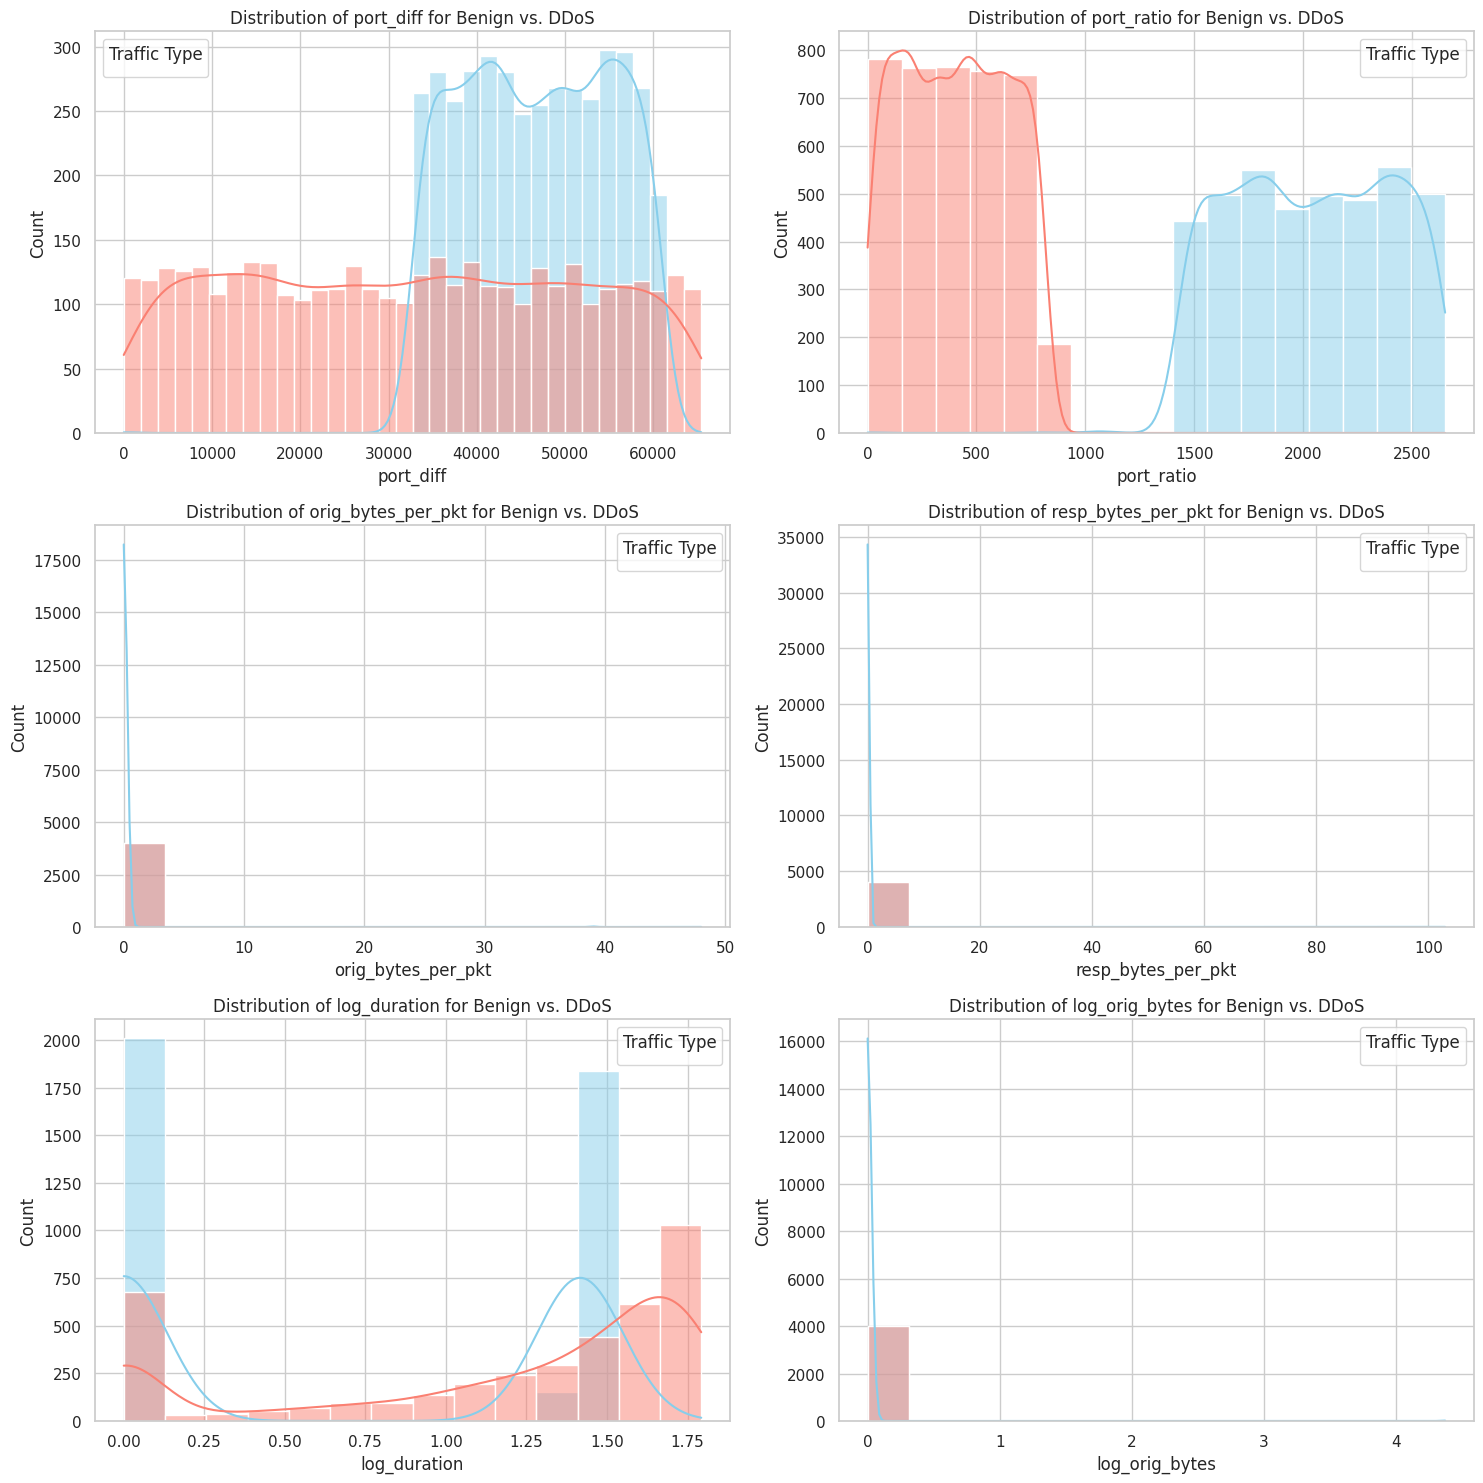

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'Benign' and 'DDoS' classes from the temporary DataFrame
df_benign_ddos = df_temp[df_temp['detailed_label'].isin(['Benign', 'DDoS'])].copy()

print("Visualizing distributions of new features for Benign vs. DDoS:\n")

# Plotting distributions of new features
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

new_features_to_plot = [
    'port_diff', 'port_ratio', 'orig_bytes_per_pkt', 'resp_bytes_per_pkt', 'log_duration', 'log_orig_bytes'
]

for i, feature in enumerate(new_features_to_plot):
    if feature in df_benign_ddos.columns:
        sns.histplot(
            data=df_benign_ddos,
            x=feature,
            hue='detailed_label',
            kde=True,
            ax=axes[i],
            palette={'Benign': 'skyblue', 'DDoS': 'salmon'},
            common_norm=False # Normalize histograms independently
        )
        axes[i].set_title(f'Distribution of {feature} for Benign vs. DDoS')
        axes[i].legend(title='Traffic Type')
    else:
        axes[i].set_visible(False) # Hide unused subplots

plt.tight_layout()
plt.savefig('engineered_feature_distributions.png', dpi=300)
plt.show()

In [13]:
import pandas as pd
import numpy as np

# Load the pruned Saab feature matrix (already processed with DFT)
df_pruned = pd.read_csv('pruned_feature_matrix.csv')

# The `df_temp` DataFrame contains the newly engineered features and 'detailed_label'.
# We need to ensure that `df_pruned` and `df_temp` have a consistent order or common index
# for merging. Since both were derived from 'balanced_train.csv' in sequential processing,
# we can assume their row order corresponds, allowing a direct concatenation of features.

# Select only the new engineered features from df_temp (excluding 'detailed_label' and original features)
newly_engineered_feature_names = [
    'port_diff', 'port_ratio', 'orig_bytes_per_pkt', 'resp_bytes_per_pkt',
    'log_duration', 'log_orig_bytes', 'log_resp_bytes'
]

df_new_features = df_temp[newly_engineered_feature_names].reset_index(drop=True)

# The 'label' column in df_pruned corresponds to 'detailed_label' from the original data.
# We will keep this label column from df_pruned.

# Concatenate the Saab features with the new engineered features
# Drop the 'label' column from df_pruned temporarily for concatenation, then re-add it.
label_column = df_pruned['label']
df_saab_features_only = df_pruned.drop(columns=['label'])

df_augmented_features = pd.concat([df_saab_features_only, df_new_features], axis=1)

# Re-add the label column
df_augmented_features['label'] = label_column

print("Augmented feature matrix created successfully.")
print("Shape of the augmented feature matrix:", df_augmented_features.shape)
display(df_augmented_features.head())

# Save the augmented feature matrix for later use
df_augmented_features.to_csv('augmented_feature_matrix.csv', index=False)
print("Augmented feature matrix saved to 'augmented_feature_matrix.csv'.")

Augmented feature matrix created successfully.
Shape of the augmented feature matrix: (25579, 16)


,saab_feat_7,saab_feat_3,saab_feat_6,saab_feat_5,saab_feat_4,saab_feat_8,saab_feat_1,saab_feat_2,port_diff,port_ratio,orig_bytes_per_pkt,resp_bytes_per_pkt,log_duration,log_orig_bytes,log_resp_bytes,label
0,6.469887,4.253091,43.874062,72.204815,129.006824,72.897437,0.021666,19.122914,50444,631.549992,0.0,0.0,0.855149,0.0,0.0,DDoS
1,6.428836,4.206848,43.963114,72.151730,128.991443,72.896135,0.022179,19.122772,52375,655.687492,0.0,0.0,0.634597,0.0,0.0,DDoS
2,5.495045,3.370279,43.046072,72.756211,128.634195,72.814156,0.025883,19.114373,48315,597.481474,0.0,0.0,0.000000,0.0,0.0,PortScan
3,6.758318,4.473272,44.607011,71.741325,129.115231,72.929867,0.022630,19.126744,59125,2571.652062,0.0,0.0,0.722773,0.0,0.0,Attack
4,6.650589,4.451237,43.477670,72.441320,129.072482,72.903356,0.019364,19.122925,41967,1825.652095,0.0,0.0,1.409826,0.0,0.0,Benign


Augmented feature matrix saved to 'augmented_feature_matrix.csv'.


Starting 5-Fold Stratified Cross-Validation with augmented features...

--- Fold 1/5 ---
  Fold Accuracy: 0.9934
  Fold Benign F1-score: 0.9988

--- Fold 2/5 ---
  Fold Accuracy: 0.9951
  Fold Benign F1-score: 0.9963

--- Fold 3/5 ---
  Fold Accuracy: 0.9975
  Fold Benign F1-score: 0.9994

--- Fold 4/5 ---
  Fold Accuracy: 0.9971
  Fold Benign F1-score: 0.9981

--- Fold 5/5 ---
  Fold Accuracy: 0.9975
  Fold Benign F1-score: 0.9988

--- Cross-Validation Summary with Augmented Features ---
Average Accuracy across 5 folds: 0.9961 ± 0.0016
Average Benign F1-score across 5 folds: 0.9983 ± 0.0011

--- Generating Overall Cross-Validation Confusion Matrix (Augmented Features) ---
Saved overall cross-validation confusion matrix plot to 'cross_validation_confusion_matrix_augmented.png'!


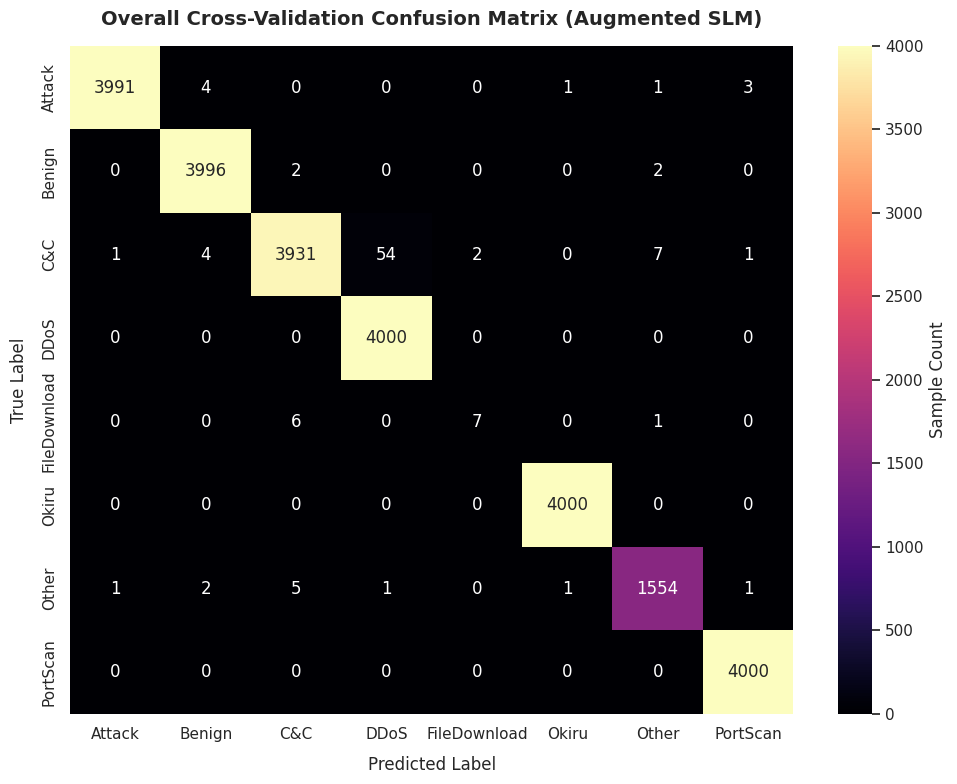

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Re-define Temporary Modified Classes (if necessary due to kernel state) ---
# These classes are crucial for the SLM model and its hyperparameter tuning.
# Ensure they are available in the current execution context.

# Define the SLMNode class
class SLMNode:
    def __init__(self, depth=0, max_depth=6, min_samples_split=10,
                 n_projections=30, active_features_range=(2, 5), n_bins=16):
        self.depth = depth
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_projections = n_projections
        self.active_features_range = active_features_range
        self.n_bins = n_bins

        self.is_leaf = False
        self.prediction = None
        self.left = None
        self.right = None

        self.projection_vector = None   # Vector 'a'
        self.selected_indices = None   # Active feature indices
        self.threshold = None          # Scalar threshold 't'

    def _compute_entropy(self, y):
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-12))

    def _generate_dft_weighted_projection(self, num_features, dft_losses):
        k = np.random.randint(self.active_features_range[0],
                              min(self.active_features_range[1] + 1, num_features + 1))
        active_indices = np.random.choice(num_features, size=k, replace=False)

        raw_coefficients = np.random.uniform(-1.0, 1.0, size=k)
        selected_dft_losses = dft_losses[active_indices]
        inv_dft_weights = 1.0 / (selected_dft_losses + 1e-8)

        a_k = raw_coefficients * inv_dft_weights

        norm = np.linalg.norm(a_k)
        if norm > 0:
            a_k = a_k / norm

        return active_indices, a_k

    def fit(self, X, y, dft_losses):
        unique_classes, counts = np.unique(y, return_counts=True)
        self.prediction = unique_classes[np.argmax(counts)]

        if (self.depth >= self.max_depth or
            len(y) < self.min_samples_split or
            len(unique_classes) == 1):
            self.is_leaf = True
            return

        best_gain = -1.0
        best_indices = None
        best_a_k = None
        best_threshold = None

        current_entropy = self._compute_entropy(y)
        N = len(y)

        for _ in range(self.n_projections):
            indices, a_k = self._generate_dft_weighted_projection(X.shape[1], dft_losses)
            X_projected = np.dot(X[:, indices], a_k)

            bins = np.linspace(np.min(X_projected), np.max(X_projected), self.n_bins + 1)
            for t in bins[1:-1]:
                left_mask = X_projected <= t
                right_mask = ~left_mask

                N_L, N_R = np.sum(left_mask), np.sum(right_mask)
                if N_L == 0 or N_R == 0:
                    continue

                H_L = self._compute_entropy(y[left_mask])
                H_R = self._compute_entropy(y[right_mask])
                weighted_H = (N_L / N) * H_L + (N_R / N) * H_R
                info_gain = current_entropy - weighted_H

                if info_gain > best_gain:
                    best_gain = info_gain
                    best_indices = indices
                    best_a_k = a_k
                    best_threshold = t

        if best_gain <= 0 or best_indices is None:
            self.is_leaf = True
            return

        self.selected_indices = best_indices
        self.projection_vector = best_a_k
        self.threshold = best_threshold

        X_projected_best = np.dot(X[:, best_indices], best_a_k)
        left_mask = X_projected_best <= best_threshold
        right_mask = ~left_mask

        self.left = SLMNode(self.depth + 1, self.max_depth, self.min_samples_split,
                            self.n_projections, self.active_features_range, self.n_bins)
        self.right = SLMNode(self.depth + 1, self.max_depth, self.min_samples_split,
                             self.n_projections, self.active_features_range, self.n_bins)

        self.left.fit(X[left_mask], y[left_mask], dft_losses)
        self.right.fit(X[right_mask], y[right_mask], dft_losses)

    def predict_one(self, x):
        if self.is_leaf:
            return self.prediction

        val = np.dot(x[self.selected_indices], self.projection_vector)
        if val <= self.threshold:
            return self.left.predict_one(x)
        else:
            return self.right.predict_one(x)


# Define the SubspaceLearningMachine class
class SubspaceLearningMachine:
    def __init__(self, max_depth=6, min_samples_split=10, n_projections=30, n_bins=16, random_state=42, active_features_range=(2, 5)):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_projections = n_projections
        self.n_bins = n_bins
        self.random_state = random_state
        self.root = None
        self.active_features_range = active_features_range # Store the new parameter

    def fit(self, X, y, dft_losses):
        np.random.seed(self.random_state)
        self.root = SLMNode(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            n_projections=self.n_projections,
            n_bins=self.n_bins,
            active_features_range=self.active_features_range # Pass the tunable parameter
        )
        self.root.fit(X, y, dft_losses)

    def predict(self, X):
        return np.array([self.root.predict_one(x) for x in X])

# Define the compute_dft_losses function
def compute_dft_losses(X, y, n_bins=16):
    dft_losses = []
    unique_labels, y_encoded = np.unique(y, return_inverse=True)
    N = len(y)

    for col_idx in range(X.shape[1]):
        x = X[:, col_idx]
        if np.min(x) == np.max(x):
            dft_losses.append(1.0)
            continue

        bins = np.linspace(np.min(x), np.max(x), n_bins + 1)
        bin_idx = np.digitize(x, bins[:-1])
        min_entropy = float('inf')

        for b in range(1, n_bins):
            left_mask = bin_idx <= b
            right_mask = ~left_mask
            N_L, N_R = np.sum(left_mask), np.sum(right_mask)
            if N_L == 0 or N_R == 0:
                continue
            _, counts_L = np.unique(y_encoded[left_mask], return_counts=True)
            H_L = -np.sum((counts_L / N_L) * np.log2((counts_L / N_L) + 1e-12))
            _, counts_R = np.unique(y_encoded[right_mask], return_counts=True)
            H_R = -np.sum((counts_R / N_R) * np.log2((counts_R / N_R) + 1e-12))

            weighted_H = (N_L / N) * H_L + (N_R / N) * H_R
            if weighted_H < min_entropy:
                min_entropy = weighted_H

        dft_losses.append(min_entropy)

    return np.array(dft_losses)


# Load the augmented feature matrix
df_full_augmented = pd.read_csv('augmented_feature_matrix.csv')
X_full_augmented = df_full_augmented[[col for col in df_full_augmented.columns if col != 'label']].values
y_full_augmented = df_full_augmented['label'].values

# Best parameters from previous hyperparameter tuning
# 'best_params': max_depth=8, n_projections=40, n_bins=32, active_features_range=(3, 6)
best_max_depth = 8
best_n_projections = 40
best_n_bins = 32
best_active_features_range = (3, 6)

# Initialize StratifiedKFold
n_splits = 5 # Using 5 folds for cross-validation
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store results from each fold
fold_accuracies_augmented = []
fold_f1_benign_augmented = []

# Lists to store all true and predicted labels for the final confusion matrix
all_y_true_augmented = []
all_y_pred_augmented = []

print(f"Starting {n_splits}-Fold Stratified Cross-Validation with augmented features...")

for fold, (train_index, val_index) in enumerate(skf.split(X_full_augmented, y_full_augmented)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    X_train_fold, X_val_fold = X_full_augmented[train_index], X_full_augmented[val_index]
    y_train_fold, y_val_fold = y_full_augmented[train_index], y_full_augmented[val_index]

    # Recompute DFT losses for the training data of the current fold
    # This is important as DFT losses are data-dependent and new features are added.
    dft_losses_fold_augmented = compute_dft_losses(X_train_fold, y_train_fold, n_bins=best_n_bins)

    # Initialize and train SLM with best parameters
    slm_cv_augmented = SubspaceLearningMachine(
        max_depth=best_max_depth,
        min_samples_split=10,
        n_projections=best_n_projections,
        n_bins=best_n_bins,
        active_features_range=best_active_features_range,
        random_state=42
    )
    slm_cv_augmented.fit(X_train_fold, y_train_fold, dft_losses_fold_augmented)

    # Predict on the validation set
    y_pred_cv_augmented = slm_cv_augmented.predict(X_val_fold)

    # Store true and predicted labels for overall confusion matrix
    all_y_true_augmented.extend(y_val_fold)
    all_y_pred_augmented.extend(y_pred_cv_augmented)

    # Evaluate performance for the current fold
    fold_accuracy_augmented = accuracy_score(y_val_fold, y_pred_cv_augmented)
    report_cv_augmented = classification_report(y_val_fold, y_pred_cv_augmented, output_dict=True, zero_division=0)
    fold_f1_augmented = report_cv_augmented.get('Benign', {}).get('f1-score', 0.0) # Handle cases where 'Benign' might not be in report

    print(f"  Fold Accuracy: {fold_accuracy_augmented:.4f}")
    print(f"  Fold Benign F1-score: {fold_f1_augmented:.4f}")

    fold_accuracies_augmented.append(fold_accuracy_augmented)
    fold_f1_benign_augmented.append(fold_f1_augmented)

print("\n--- Cross-Validation Summary with Augmented Features ---")
print(f"Average Accuracy across {n_splits} folds: {np.mean(fold_accuracies_augmented):.4f} \u00B1 {np.std(fold_accuracies_augmented):.4f}")
print(f"Average Benign F1-score across {n_splits} folds: {np.mean(fold_f1_benign_augmented):.4f} \u00B1 {np.std(fold_f1_benign_augmented):.4f}")

# --- Overall Confusion Matrix for Cross-Validation with Augmented Features ---
print("\n--- Generating Overall Cross-Validation Confusion Matrix (Augmented Features) ---")
class_names = sorted(np.unique(y_full_augmented)) # Get all unique class names from the full dataset
cm_cv_augmented = confusion_matrix(all_y_true_augmented, all_y_pred_augmented, labels=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_cv_augmented,
    annot=True,
    fmt='d',
    cmap='magma',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Sample Count'}
)

plt.title('Overall Cross-Validation Confusion Matrix (Augmented SLM)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.tight_layout()
plt.savefig('cross_validation_confusion_matrix_augmented.png', dpi=300)
print("Saved overall cross-validation confusion matrix plot to 'cross_validation_confusion_matrix_augmented.png'!")
plt.show()

### Save the trained SLM Model

Now that the model has been evaluated using cross-validation, a final model will be trained on the entire augmented dataset and saved for future use. This ensures the model captures the full patterns from the training data.

In [15]:
import pickle

# Recompute DFT losses for the entire augmented dataset
print("Recomputing DFT losses for the full augmented dataset...")
dft_losses_full_augmented = compute_dft_losses(X_full_augmented, y_full_augmented, n_bins=best_n_bins)

# Train the final SLM model on the entire augmented dataset using best parameters
print("Training final SLM model on the entire augmented dataset...")
final_slm_model = SubspaceLearningMachine(
    max_depth=best_max_depth,
    min_samples_split=10,
    n_projections=best_n_projections,
    n_bins=best_n_bins,
    active_features_range=best_active_features_range,
    random_state=42
)
final_slm_model.fit(X_full_augmented, y_full_augmented, dft_losses_full_augmented)

# Save the trained model
model_filename = 'slm_iot23_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(final_slm_model, file)

print(f"Final SLM model saved successfully to '{model_filename}'")

Recomputing DFT losses for the full augmented dataset...
Training final SLM model on the entire augmented dataset...
Final SLM model saved successfully to 'slm_iot23_model.pkl'
